In [2]:
import pandas as pd
import numpy as np

# 读取 CSV 文件并处理为正确格式（使用分号分隔）
file_path = '结果.csv'  # 请根据实际路径替换
data = pd.read_csv(file_path, delimiter=';')

# 提取相关的列
age_column = data.iloc[:, 1]  # 年龄列
profession_column = data.iloc[:, 2]  # 职业/身份列
understand_column = data.iloc[:, 5]  # 了解AI的程度列
channel_column = data.iloc[:, 6]  # 信息获取渠道列

# 计算“了解一些”与“非常了解”AI的学生和教师的百分比
student_understand_some = profession_column[profession_column == '学生'].apply(lambda x: '了解一些' in understand_column[profession_column == x].values).sum()
teacher_understand_some = profession_column[profession_column == '教育从业者'].apply(lambda x: '了解一些' in understand_column[profession_column == x].values).sum()

student_very_understand = profession_column[profession_column == '学生'].apply(lambda x: '非常了解' in understand_column[profession_column == x].values).sum()
teacher_very_understand = profession_column[profession_column == '教育从业者'].apply(lambda x: '非常了解' in understand_column[profession_column == x].values).sum()

# 计算百分比
student_understand_some_percentage = (student_understand_some / len(profession_column[profession_column == '学生'])) * 100
teacher_understand_some_percentage = (teacher_understand_some / len(profession_column[profession_column == '教育从业者'])) * 100

student_very_understand_percentage = (student_very_understand / len(profession_column[profession_column == '学生'])) * 100
teacher_very_understand_percentage = (teacher_very_understand / len(profession_column[profession_column == '教育从业者'])) * 100

# 分析学生和教师获取信息的渠道
student_channels = channel_column[profession_column == '学生'].str.contains('社交平台').sum(), channel_column[profession_column == '学生'].str.contains('新闻媒体').sum()
teacher_channels = channel_column[profession_column == '教育从业者'].str.contains('课程培训').sum(), channel_column[profession_column == '教育从业者'].str.contains('工作实践').sum()

student_channels_percentage = [val / len(profession_column[profession_column == '学生']) * 100 for val in student_channels]
teacher_channels_percentage = [val / len(profession_column[profession_column == '教育从业者']) * 100 for val in teacher_channels]

# 输出分析结果
print(f"学生群体中，{student_understand_some_percentage:.2f}%表示‘了解一些’，而{student_very_understand_percentage:.2f}%的学生表示‘非常了解’AI")
print(f"教师群体中，{teacher_understand_some_percentage:.2f}%表示‘了解一些’，而{teacher_very_understand_percentage:.2f}%的教师表示‘非常了解’AI")

print(f"在信息获取渠道方面，学生群体高度依赖社交平台（{student_channels_percentage[0]:.2f}%）和新闻媒体（{student_channels_percentage[1]:.2f}%）")
print(f"教师群体则更倾向于通过课程培训（{teacher_channels_percentage[0]:.2f}%）和工作实践（{teacher_channels_percentage[1]:.2f}%）获取信息")


学生群体中，100.00%表示‘了解一些’，而100.00%的学生表示‘非常了解’AI
教师群体中，100.00%表示‘了解一些’，而100.00%的教师表示‘非常了解’AI
在信息获取渠道方面，学生群体高度依赖社交平台（73.17%）和新闻媒体（2.44%）
教师群体则更倾向于通过课程培训（56.00%）和工作实践（36.00%）获取信息


In [4]:
import pandas as pd

FILE_PATH = "结果.csv"

# 1) 读取分号分隔CSV
df = pd.read_csv(FILE_PATH, delimiter=";")

# 2) 字段映射（按你这份CSV的列号）
COL_PROF = "2"   # 职业/身份
COL_ATT  = "11"  # 对AI发展态度
COL_WOR  = "12"  # 担忧哪些方面（多选，逗号分隔）
COL_DEC  = "13"  # 是否愿意重要决策交给AI（是/否）
COL_REG  = "14"  # 是否需要伦理规范与政府监管（是/否）
COL_WMK  = "16"  # 是否支持强制水印（是/否）

STU_LABEL = "学生"
TEA_LABEL = "教育从业者"

def pct(count: int, total: int) -> float:
    return round(count / total * 100, 2) if total else 0.0

def count_multiselect(series: pd.Series, option: str) -> int:
    """
    统计多选题中包含某个选项的次数。
    该CSV里多选字段用英文逗号','拼接；缺失为NaN。
    """
    s = series.fillna("").astype(str)
    # 精确按“逗号分割后的选项”匹配
    return s.apply(lambda x: option in [p.strip() for p in x.split(",") if p.strip()]).sum()

# 3) 分组
students = df[df[COL_PROF] == STU_LABEL].copy()
teachers = df[df[COL_PROF] == TEA_LABEL].copy()

n_stu = len(students)
n_tea = len(teachers)

# 4) “比较乐观”比例
stu_att_bjlg = pct((students[COL_ATT] == "比较乐观").sum(), n_stu)
tea_att_bjlg = pct((teachers[COL_ATT] == "比较乐观").sum(), n_tea)

# 5) 担忧（多选）比例
worry_options = ["失业", "隐私泄露", "失控风险", "算法偏见", "社会不平等加剧"]

stu_worry_pct = {opt: pct(count_multiselect(students[COL_WOR], opt), n_stu) for opt in worry_options}
tea_worry_pct = {opt: pct(count_multiselect(teachers[COL_WOR], opt), n_tea) for opt in worry_options}

# 6) 水印、监管、重要决策意愿
stu_watermark = pct((students[COL_WMK] == "是").sum(), n_stu)
tea_watermark = pct((teachers[COL_WMK] == "是").sum(), n_tea)

stu_regulation = pct((students[COL_REG] == "是").sum(), n_stu)
tea_regulation = pct((teachers[COL_REG] == "是").sum(), n_tea)

stu_willing_decision = pct((students[COL_DEC] == "是").sum(), n_stu)
tea_willing_decision = pct((teachers[COL_DEC] == "是").sum(), n_tea)

# 7) 打印结果（你也可以把这些值填回文字里）
print(f"样本量：学生={n_stu}，教师/教育从业者={n_tea}")

print("\n【态度：比较乐观】")
print(f"学生：{stu_att_bjlg:.2f}%")
print(f"教师：{tea_att_bjlg:.2f}%")

print("\n【担忧（多选）】")
print("学生：")
for k, v in stu_worry_pct.items():
    print(f"  {k}：{v:.2f}%")
print("教师：")
for k, v in tea_worry_pct.items():
    print(f"  {k}：{v:.2f}%")

print("\n【伦理与治理】")
print(f"支持强制水印：学生={stu_watermark:.2f}%；教师={tea_watermark:.2f}%")
print(f"需要伦理规范与政府监管：学生={stu_regulation:.2f}%；教师={tea_regulation:.2f}%")

print("\n【重要决策愿意交给AI（是）】")
print(f"学生：{stu_willing_decision:.2f}%")
print(f"教师：{tea_willing_decision:.2f}%")


样本量：学生=41，教师/教育从业者=25

【态度：比较乐观】
学生：65.85%
教师：36.00%

【担忧（多选）】
学生：
  失业：65.85%
  隐私泄露：70.73%
  失控风险：9.76%
  算法偏见：29.27%
  社会不平等加剧：12.20%
教师：
  失业：28.00%
  隐私泄露：96.00%
  失控风险：20.00%
  算法偏见：48.00%
  社会不平等加剧：56.00%

【伦理与治理】
支持强制水印：学生=100.00%；教师=100.00%
需要伦理规范与政府监管：学生=100.00%；教师=100.00%

【重要决策愿意交给AI（是）】
学生：31.71%
教师：44.00%


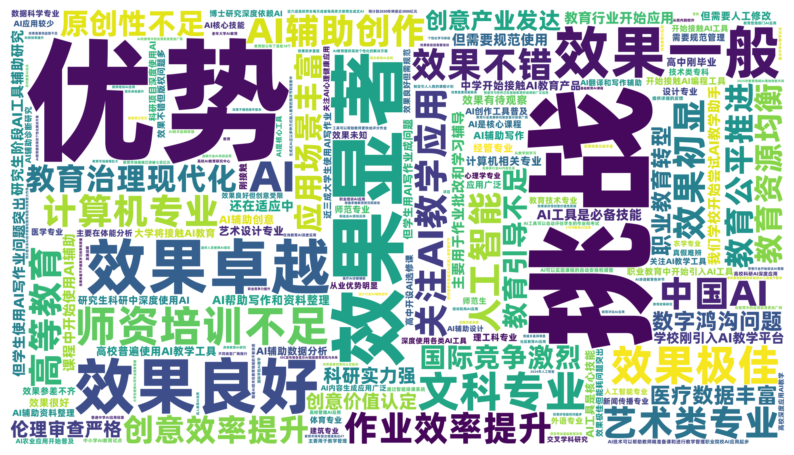

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


font_path = './ALIBABAPUHUITI-3-105-HEAVY.TTF'

df = pd.read_csv(FILE_PATH, delimiter=";")

# 将所有问答内容合并成一个字符串
responses = ' '.join(df.iloc[:, 10].dropna().astype(str))
responses += ' '.join(df.iloc[:, 21].dropna().astype(str))
responses += ' '.join(df.iloc[:, 22].dropna().astype(str))

# 创建词云
wordcloud = WordCloud(width=1920, height=1080, background_color='white', font_path=font_path).generate(responses)

# 显示词云图
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

P^T @ P (should be identity):
 [[1.00000000e+00 1.48741681e-17]
 [1.48741681e-17 1.00000000e+00]]

旋转角度: 60°
原始点 A: [1. 0.]
变换后点 B = P^T @ A: [0.5       0.8660254]
理论预期 (cosθ, sinθ): [0.5       0.8660254]
误差: 0.0


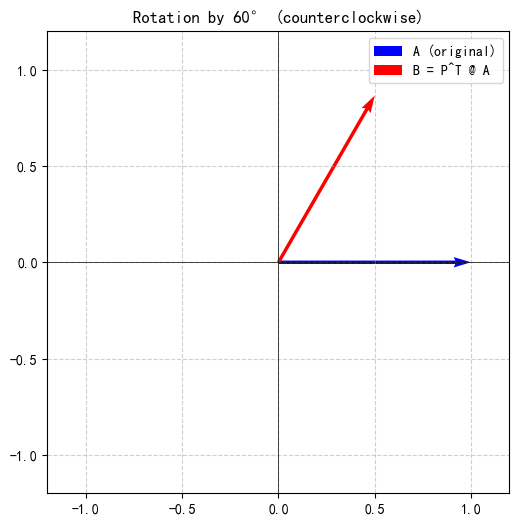

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# 设置旋转角度（例如 60 度）
theta_deg = 60
theta = np.radians(theta_deg)

# 构造图片中的 P 矩阵（注意：这是顺时针旋转 θ 的矩阵）
P = np.array([
    [np.cos(theta),  np.sin(theta)],
    [-np.sin(theta), np.cos(theta)]
])

# 验证：P 是正交矩阵吗？
print("P^T @ P (should be identity):\n", P.T @ P)

# 原始点 A（列向量）
A = np.array([1.0, 0.0])  # x轴上的点

# 使用 P^T 进行变换：B = P^T @ A
B = P.T @ A

print(f"\n旋转角度: {theta_deg}°")
print("原始点 A:", A)
print("变换后点 B = P^T @ A:", B)

# 预期结果：逆时针旋转 theta 后的坐标
expected = np.array([np.cos(theta), np.sin(theta)])
print("理论预期 (cosθ, sinθ):", expected)
print("误差:", np.linalg.norm(B - expected))

# 可选：画图可视化
plt.figure(figsize=(6,6))
plt.quiver(0, 0, A[0], A[1], angles='xy', scale_units='xy', scale=1, color='blue', label='A (original)')
plt.quiver(0, 0, B[0], B[1], angles='xy', scale_units='xy', scale=1, color='red', label='B = P^T @ A')
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.title(f'Rotation by {theta_deg}° (counterclockwise)')
plt.gca().set_aspect('equal')
plt.show()